In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('loan_approval_dataset.csv')

In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
X=df.iloc[:,1:12]
y=df.iloc[:,12:13]

In [5]:
y[' loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [6]:
X.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value'],
      dtype='object')

In [7]:
y[' loan_status']=y[' loan_status'].map({" Approved":1," Rejected":0})

In [8]:
y.rename(columns={" loan_status":"loan_status"},inplace=True)

In [9]:
education=pd.get_dummies(X[' education'],drop_first=True,dtype=int)

In [10]:
self_employed=pd.get_dummies(X[' self_employed'],drop_first=True,dtype=int)

In [11]:
X=X.drop(columns=[' education',' self_employed'],axis=1)

In [12]:
X=pd.concat([X,education,self_employed],axis=1)

In [13]:
X

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,Not Graduate,Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0,0
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1,1
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1000000,2300000,12,317,2800000,500000,3300000,800000,0,1
4265,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,1
4266,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1,0
4267,1,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,0


In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [15]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [16]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ReLU,ELU,LeakyReLU,PReLU
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

In [17]:
model=tf.keras.Sequential(
    [
        tf.keras.layers.Dense(32,input_shape=(11,),activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16,activation='relu'),
        tf.keras.layers.Dense(1,activation='sigmoid')      
    ]
)


c:\Users\vinot\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta = 0.001,
    patience=5,
    verbose = 1,
    mode= "min",
    baseline= None,
    restore_best_weights= True,
    start_from_epoch = 0

)

In [19]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model_history=model.fit(X_train,y_train,validation_split=0.22,batch_size=32,epochs=100,callbacks=early_stopping)

Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6237 - loss: 0.6654 - val_accuracy: 0.8657 - val_loss: 0.5488
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8460 - loss: 0.4649 - val_accuracy: 0.9096 - val_loss: 0.3315
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8926 - loss: 0.3068 - val_accuracy: 0.9176 - val_loss: 0.2309
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9012 - loss: 0.2561 - val_accuracy: 0.9269 - val_loss: 0.2022
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9076 - loss: 0.2363 - val_accuracy: 0.9322 - val_loss: 0.1895
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2250 - val_accuracy: 0.9375 - val_loss: 0.1793
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9174 - loss: 0.2146 - val_accuracy: 0.9309 - val_loss: 0.1741
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9118 - loss: 0.2100 - val_accuracy: 0.9362 - v

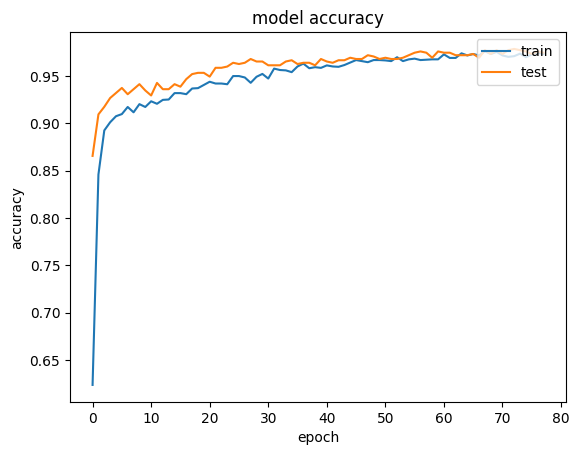

In [20]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='upper right')
plt.show()

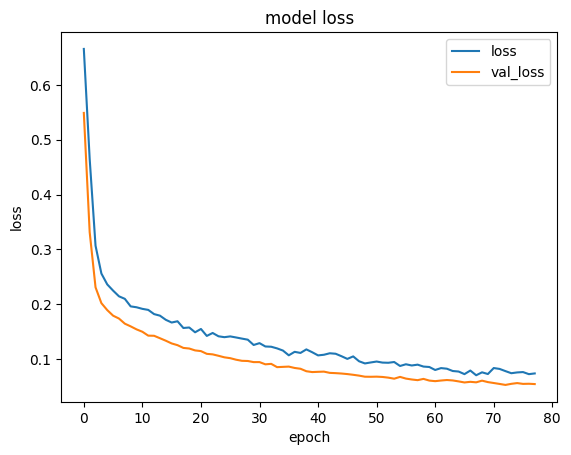

In [21]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['loss','val_loss'],loc='upper right')
plt.show()

In [22]:
y_pred=model.predict(X_test)
y_pred=(y_pred>=0.5)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [25]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
cm=confusion_matrix(y_pred,y_test)
ac=accuracy_score(y_pred,y_test)
cr=classification_report(y_pred,y_test)
print(cm)
print(ac)
print(cr)

[[323  11]
 [  8 512]]
0.977751756440281
              precision    recall  f1-score   support

       False       0.98      0.97      0.97       334
        True       0.98      0.98      0.98       520

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [24]:
model.get_weights()

[array([[ 1.45814661e-02,  3.89106311e-02,  1.34477522e-02,
          3.76450531e-02,  1.14113670e-02,  3.07324678e-02,
          1.08465664e-02, -2.34835222e-01,  1.62974969e-02,
          2.99459100e-01,  5.26605770e-02, -5.11939973e-02,
          1.39757946e-01, -8.23464766e-02,  2.97457185e-02,
          4.16938914e-03,  1.18979268e-01, -1.38347987e-02,
          1.17444303e-02,  1.29239564e-03,  2.16737203e-02,
          2.26317803e-04, -1.42150775e-01,  1.84203416e-01,
          1.59957036e-01, -1.10466294e-01, -5.80319576e-02,
         -1.99305311e-01,  8.03097561e-02,  6.74861192e-04,
          6.63050413e-02, -1.44624487e-01],
        [ 4.66413237e-02,  5.05977094e-01, -2.64599174e-01,
         -1.79708049e-01, -6.67862415e-01,  6.82732984e-02,
          1.44858122e-01, -4.98867214e-01,  1.77468315e-01,
          1.36449382e-01,  5.73362894e-02,  1.73241645e-01,
         -1.23242669e-01, -1.29062578e-01,  5.16571999e-01,
         -4.45945233e-01, -4.20587584e-02,  1.54754594e-